Used only past 24 h - Multivariative LSTM

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor

In [2]:
# Load dataset
df = pd.read_csv("boralesgamuwa_weather_2025_01_01_to_2025_12_31_15min_interpolated_power_added_final_set.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time (VERY IMPORTANT)
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,solar_normalize
0,2025-01-01 00:00:00,24.2,92.0,100.0,0.0,8.100,0.0
1,2025-01-01 00:15:00,24.1,92.5,100.0,0.0,8.275,0.0
2,2025-01-01 00:30:00,24.0,93.0,100.0,0.0,8.450,0.0
3,2025-01-01 00:45:00,23.9,93.5,100.0,0.0,8.625,0.0
4,2025-01-01 01:00:00,23.8,94.0,100.0,0.0,8.800,0.0


In [3]:
df.tail()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,solar_normalize
35035,2025-12-31 22:45:00,24.15,94.0,100.0,0.0,6.2,0.0
35036,2025-12-31 23:00:00,24.30,94.0,100.0,0.0,6.0,0.0
35037,2025-12-31 23:15:00,24.45,94.0,100.0,0.0,5.8,0.0
35038,2025-12-31 23:30:00,24.60,94.0,100.0,0.0,5.6,0.0
35039,2025-12-31 23:45:00,24.75,94.0,100.0,0.0,5.4,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             35040 non-null  datetime64[ns]
 1   temperature_C         35040 non-null  float64       
 2   humidity_percent      35040 non-null  float64       
 3   cloud_cover_percent   35040 non-null  float64       
 4   solar_irradiance_Wm2  35040 non-null  float64       
 5   wind_speed_ms         35040 non-null  float64       
 6   solar_normalize       34956 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 1.9 MB


In [5]:
#  Interpolate missing values (linear for time series)
df = df.interpolate(method="linear")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             35040 non-null  datetime64[ns]
 1   temperature_C         35040 non-null  float64       
 2   humidity_percent      35040 non-null  float64       
 3   cloud_cover_percent   35040 non-null  float64       
 4   solar_irradiance_Wm2  35040 non-null  float64       
 5   wind_speed_ms         35040 non-null  float64       
 6   solar_normalize       35040 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 1.9 MB
None


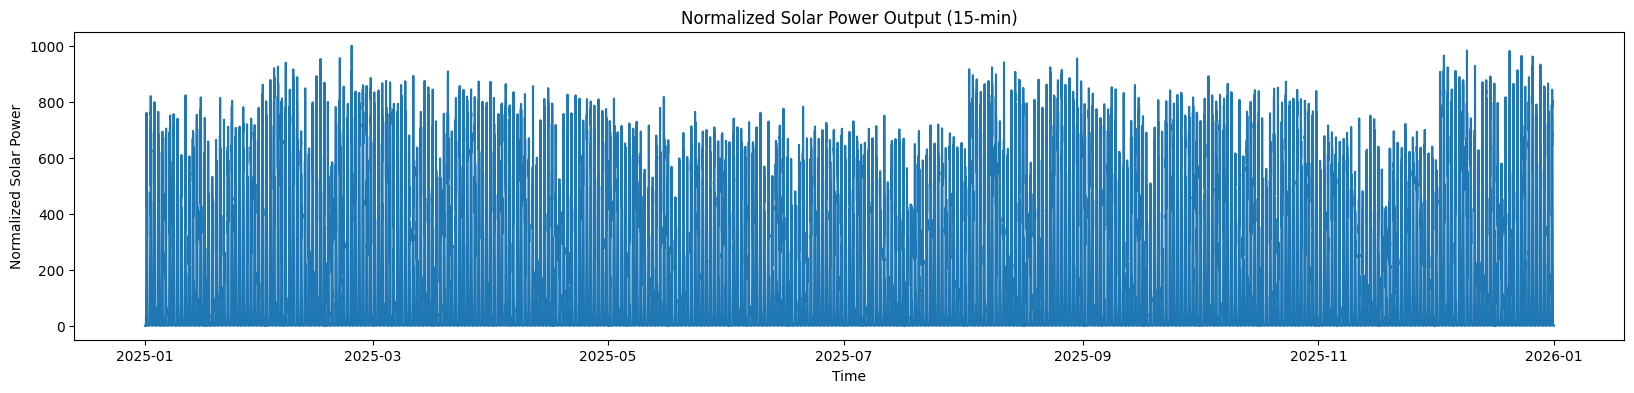

In [6]:
plt.figure(figsize=(20,4))
plt.plot(df["timestamp"], df["solar_normalize"])
plt.title("Normalized Solar Power Output (15-min)")
plt.xlabel("Time")
plt.ylabel("Normalized Solar Power")
plt.show()

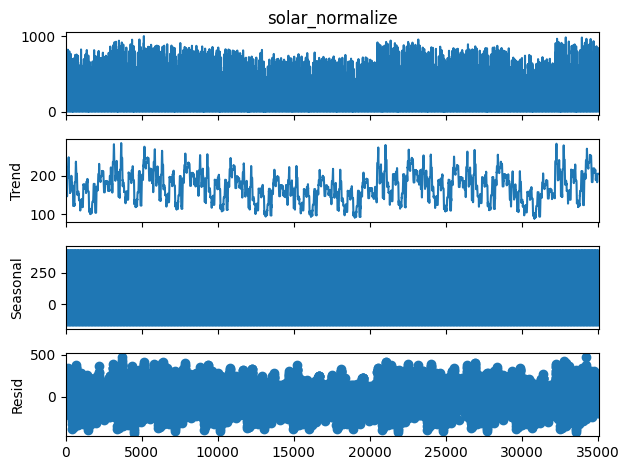

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
results = seasonal_decompose(df['solar_normalize'], model='additive', period=96)  # daily seasonality (96 intervals per day)
results.plot();

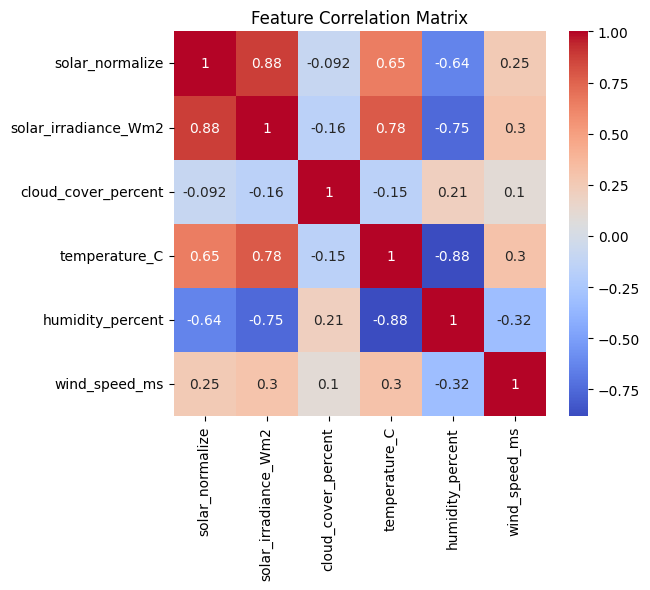

In [8]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[[
        "solar_normalize",
        "solar_irradiance_Wm2",
        "cloud_cover_percent",
        "temperature_C",
        "humidity_percent",
        "wind_speed_ms"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()

In [9]:
# # Time-based features
# df["hour"] = df["timestamp"].dt.hour
# df["minute"] = df["timestamp"].dt.minute
# df["dayofyear"] = df["timestamp"].dt.dayofyear

# # Solar power lags
# df["solar_lag_1"] = df["solar_normalize"].shift(1)
# df["solar_lag_2"] = df["solar_normalize"].shift(2)
# df["solar_lag_4"] = df["solar_normalize"].shift(4)

# #Drop NaN
# df = df.dropna()

# Ramp rate (intra-hour variability)
#df["solar_ramp"] = df["solar_normalize"] - df["solar_lag_1"]

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             35040 non-null  datetime64[ns]
 1   temperature_C         35040 non-null  float64       
 2   humidity_percent      35040 non-null  float64       
 3   cloud_cover_percent   35040 non-null  float64       
 4   solar_irradiance_Wm2  35040 non-null  float64       
 5   wind_speed_ms         35040 non-null  float64       
 6   solar_normalize       35040 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 1.9 MB


In [11]:
features = [
    "solar_normalize",
    "solar_irradiance_Wm2",
    "temperature_C",
    "wind_speed_ms"
]

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(df[features])

In [13]:
import numpy as np

n_input = 96   # past 24h
n_output = 96  # future 24h

X = []
y = []

for i in range(0, len(data_scaled) - n_input - n_output, 96):
    X.append(data_scaled[i:i+n_input])
    y.append(data_scaled[i+n_input:i+n_input+n_output, 0])  # only solar

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (363, 96, 4)
y shape: (363, 96)


In [14]:
len(X), len(y)

(363, 363)

In [15]:
train_size = int(0.7 * len(X))
val_size   = int(0.15 * len(X))

X_train = X[:train_size]
X_val   = X[train_size:train_size+val_size]
X_test  = X[train_size+val_size:]

y_train = y[:train_size]
y_val   = y[train_size:train_size+val_size]
y_test  = y[train_size+val_size:]

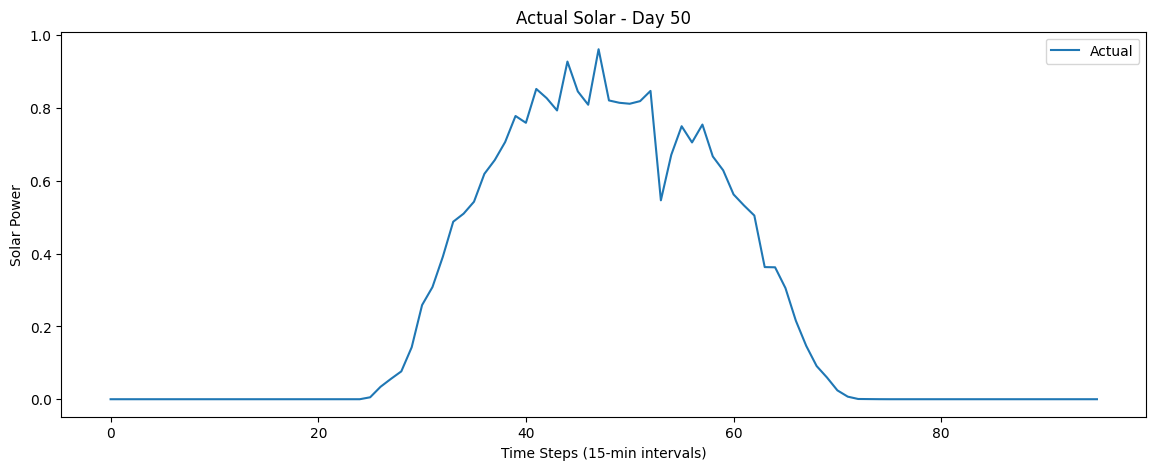

In [16]:
import matplotlib.pyplot as plt

day = 50  # change this to see different days

plt.figure(figsize=(14,5))

plt.plot(y_test[day], label="Actual")

plt.title(f"Actual Solar - Day {day}")
plt.xlabel("Time Steps (15-min intervals)")
plt.ylabel("Solar Power")
plt.legend()

plt.show()

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# First LSTM layer
model.add(LSTM(128, return_sequences=True, input_shape=(96, X.shape[2])))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(64))
model.add(Dropout(0.2))

# Output layer (96 steps)
model.add(Dense(96, activation="relu"))  # relu avoids negative values

model.compile(
    optimizer='adam',
    loss='huber'   # better than MSE for peaks
)

model.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 128)        │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │         6,240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,744 (483.38 KB)

 Trainable params: 123,744 (483.38 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train, y_train,
    epochs=30,  #20 thibbe 
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - loss: 0.0402 - val_loss: 0.0249
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - loss: 0.0227 - val_loss: 0.0125
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - loss: 0.0147 - val_loss: 0.0099
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.0118 - val_loss: 0.0080
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - loss: 0.0094 - val_loss: 0.0050
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.0079 - val_loss: 0.0051
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - loss: 0.0071 - val_loss: 0.0051
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - loss: 0.0070 - val_loss: 0.0051
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - loss: 0.0064 - val_loss: 0.0047
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 0.0067 - val_loss: 0.0047
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - loss: 0.0062 - val_loss: 0.0052
Epoch 12/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - loss: 0.0061 - val_lo

In [19]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step


In [20]:
# Create dummy arrays
y_pred_full = np.zeros((y_pred.shape[0], y_pred.shape[1], len(features)))
y_test_full = np.zeros_like(y_pred_full)

# Put solar values back (column 0)
y_pred_full[:,:,0] = y_pred
y_test_full[:,:,0] = y_test

# Inverse transform
y_pred_inv = scaler.inverse_transform(y_pred_full.reshape(-1, len(features)))[:,0]
y_test_inv = scaler.inverse_transform(y_test_full.reshape(-1, len(features)))[:,0]

# Reshape back
y_pred_inv = y_pred_inv.reshape(y_pred.shape)
y_test_inv = y_test_inv.reshape(y_test.shape)

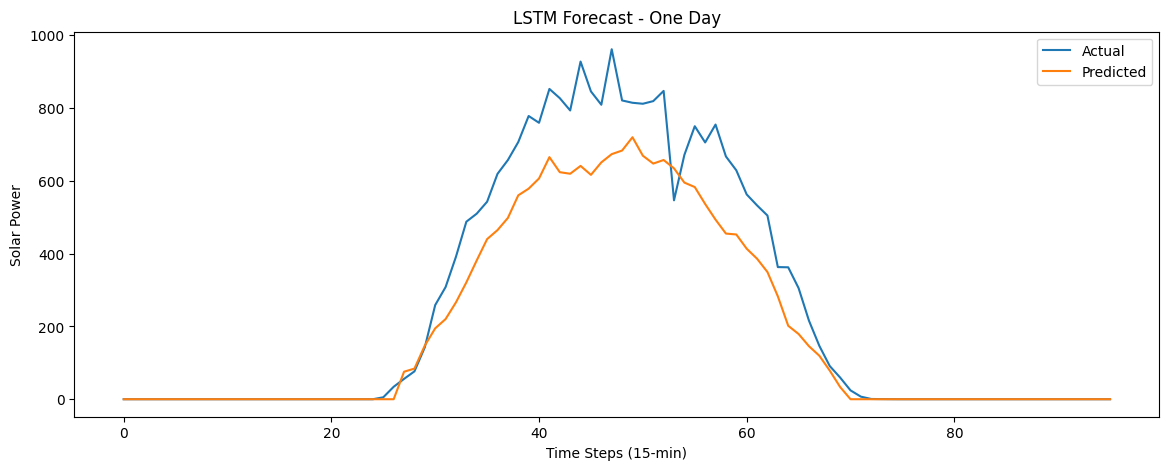

In [21]:
import matplotlib.pyplot as plt

day = 50

plt.figure(figsize=(14,5))

plt.plot(y_test_inv[day], label="Actual")
plt.plot(y_pred_inv[day], label="Predicted")

plt.legend()
plt.title("LSTM Forecast - One Day")
plt.xlabel("Time Steps (15-min)")
plt.ylabel("Solar Power")

plt.show()

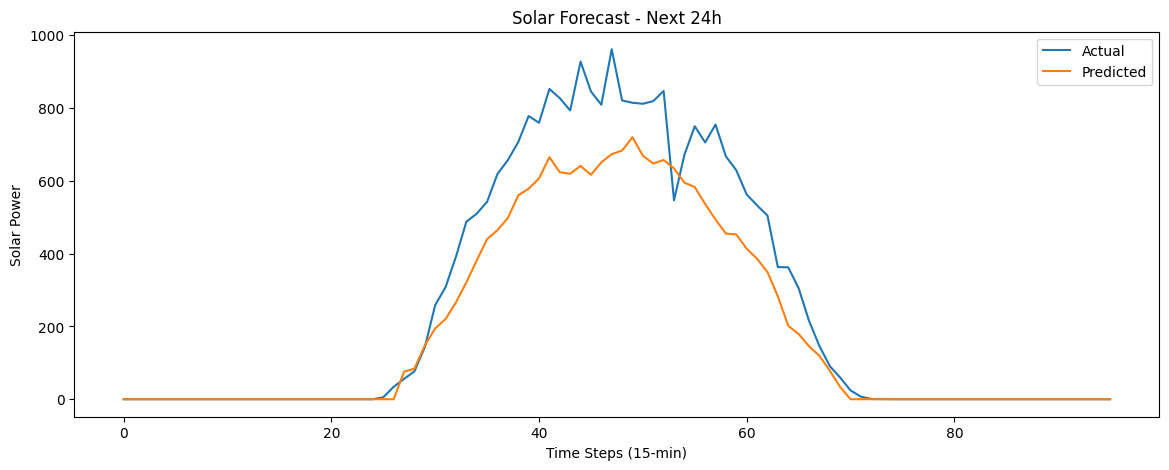

In [22]:
import matplotlib.pyplot as plt

day = 50

plt.figure(figsize=(14,5))

plt.plot(y_test_inv[day], label="Actual")
plt.plot(y_pred_inv[day], label="Predicted")

plt.legend()
plt.title("Solar Forecast - Next 24h")
plt.xlabel("Time Steps (15-min)")
plt.ylabel("Solar Power")

plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error, r2_score

y_test_flat = y_test_inv.reshape(-1)
y_pred_flat = y_pred_inv.reshape(-1)

mae = mean_absolute_error(y_test_flat, y_pred_flat)
rmse = np.sqrt(np.mean((y_test_flat - y_pred_flat)**2))
r2 = r2_score(y_test_flat, y_pred_flat)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 51.82431855682857
RMSE: 98.26775630086837
R2: 0.8392139535384857
